In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df = pd.read_csv('../data/raw/bengaluru_house_prices.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## 1. Data Cleaning

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [100]:
df = df.drop(columns=["area_type","availability","society"])

In [101]:
df.isnull().sum()

location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

As we can see we have missing values in location, total_sqft, bath and balcony so let's clean it.

In [102]:
print(df.shape)

(13320, 6)


In [103]:
df= df.dropna()

In [104]:
df.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

Now we don't have any missing values in our dataset.

In [105]:
print(df.shape)

(12710, 6)


In [106]:
df['bhk'] = df['size'].str.split().str[0]

# 3bhk -> 3
# 4bedroom -> 4
# 5 RK -> 5
df['bhk'] = pd.to_numeric(df['bhk'], errors="coerce")

"Size" feature is messy because it contain "BHK","Bedroom","RK" and for ML model text is not useful so I Have converted it to numarical feature.

### EDA

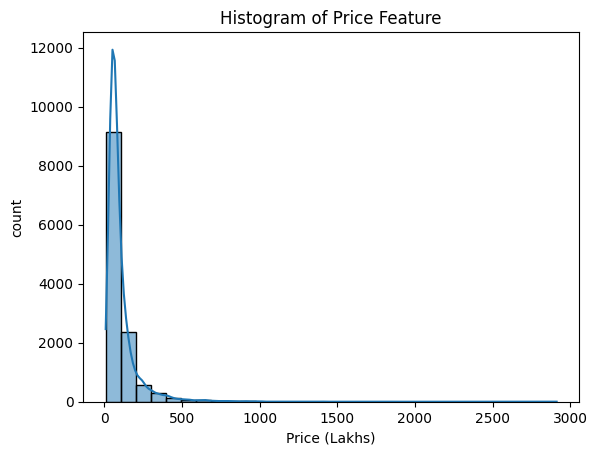

In [107]:
plt.Figure(figsize=(10,6))
sns.histplot(x= df['price'],bins=30,kde=True)
plt.title("Histogram of Price Feature")
plt.xlabel("Price (Lakhs)")
plt.ylabel('count')
plt.show()

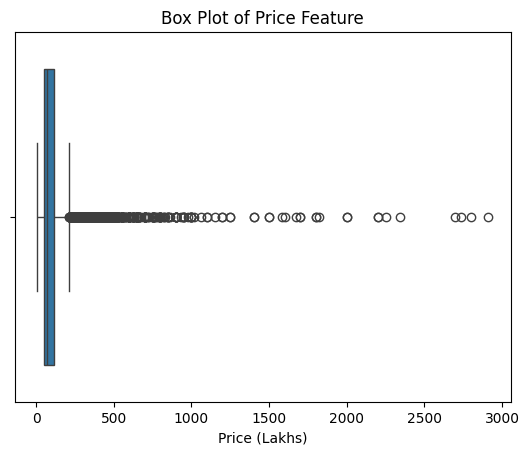

In [108]:
plt.Figure(figsize=(10,6))
sns.boxplot(x= df['price'])
plt.title("Box Plot of Price Feature")
plt.xlabel("Price (Lakhs)")
plt.show()

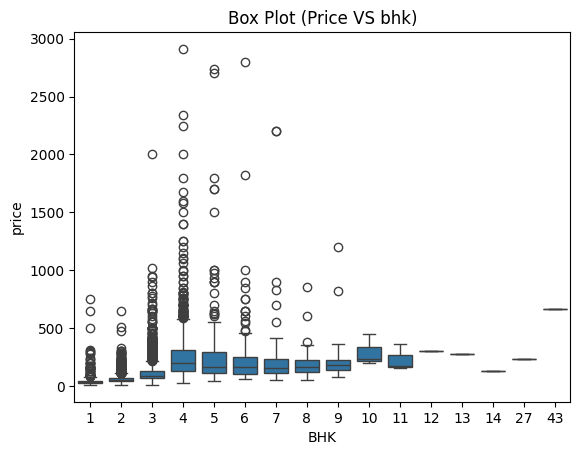

In [109]:
# box plot price vs bhk
plt.Figure(figsize=(10,6))
sns.boxplot(y= df['price'],x=df['bhk'])
plt.title("Box Plot (Price VS bhk)")
plt.xlabel("BHK")
plt.show()

As we can see we have lot's of outlier we have to fix that

## Feature Engineering

In [110]:
df.info()

<class 'pandas.DataFrame'>
Index: 12710 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    12710 non-null  str    
 1   size        12710 non-null  str    
 2   total_sqft  12710 non-null  str    
 3   bath        12710 non-null  float64
 4   balcony     12710 non-null  float64
 5   price       12710 non-null  float64
 6   bhk         12710 non-null  int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 794.4 KB


'total_sqft' feature should be in numaric but this is in str Datatype.I need to Convert it to Numaric datatype.

In [111]:
def convert_str_num_sqft(total_sqft):
    tokens = str(total_sqft).split('-')
    
    if len(tokens) == 2:
        return (float(tokens[0])+float(tokens[1]))/2

    try:
        return float(total_sqft)
    except:
        return None
    
    
df['total_sqft'] = df['total_sqft'].apply(convert_str_num_sqft)

In [112]:
# create the new feature called price_per_sqft
df['price_per_sqft'] = (df['price']* 1000000)/df['total_sqft']

With the help of 'price_per_sqft' feature we get the idea how much price per squar fit.

In [113]:
count_location = df['location'].value_counts()
rare_location = count_location[count_location <= 10].index
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_location else x)



'location' feature has lot's of location so i am just groping thoose location which is repeated less then and 10 times in the dataset.

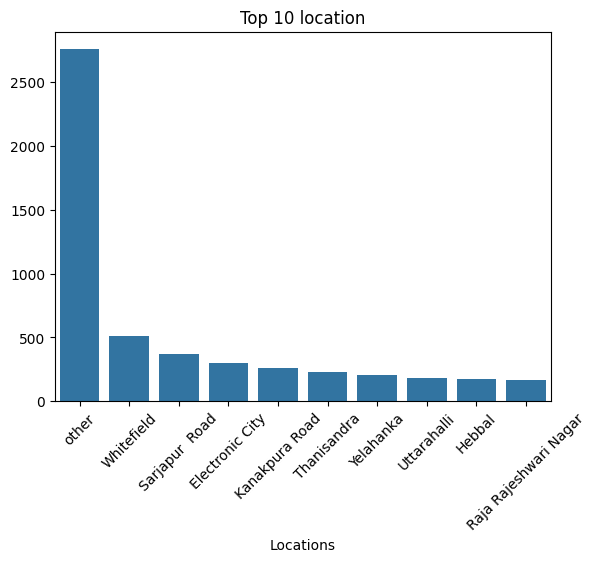

In [114]:
top_10_location = df['location'].value_counts().head(10)
plt.Figure(figsize=(10,6))
sns.barplot(x = top_10_location.index, y = top_10_location.values)
plt.xticks(rotation = 45)
plt.title("Top 10 location")
plt.xlabel("Locations")
plt.show()

In [115]:
print("bofre removing low sqft per bhk",df.shape)
df = df[(df['total_sqft'] / df['bhk']) > 300]
print("After removing low sqft per bhk",df.shape)

bofre removing low sqft per bhk (12710, 8)
After removing low sqft per bhk (11847, 8)


In [116]:
# Keep rows where number of bathrooms is reasonable
df = df[df['bath'] < df['bhk'] + 2]

print("After removing bathroom outliers:", df.shape)

After removing bathroom outliers: (11724, 8)


I have removed the bath rows which is more than rooms+2 because it dos't make ant sence.

In [117]:
# This function removes price_per_sqft outliers location-wise
def remove_pps_outliers(df):
    cleaned_df = pd.DataFrame()  # Empty DataFrame to store clean data
    
    # Group data by each location
    for location, group in df.groupby('location'):
        mean = group['price_per_sqft'].mean()
        std = group['price_per_sqft'].std()
        
        # Keep only rows where price_per_sqft is within one std deviation from mean
        filtered = group[(group['price_per_sqft'] > (mean - std)) & 
                         (group['price_per_sqft'] <= (mean + std))]
        
        cleaned_df = pd.concat([cleaned_df, filtered], ignore_index=True)
    
    return cleaned_df

# Apply the function to clean the dataset
df = remove_pps_outliers(df)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

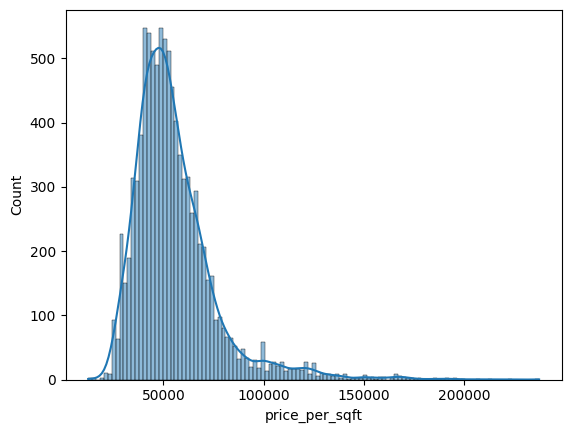

In [118]:
sns.histplot(x=df['price_per_sqft'], kde=True)

In [119]:
# This function removes BHK-based pricing outliers for each location
def remove_bhk_outliers(df):
    indices_to_remove = []  # Store indexes of outliers

    # Group data by each location
    for location, location_df in df.groupby('location'):
        # Create a dictionary to store price stats for each BHK level
        bhk_price_stats = {}

        # Loop through each BHK group in that location
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_price_stats[bhk] = {
                'mean_price': bhk_df['price_per_sqft'].mean(),
                'std_dev': bhk_df['price_per_sqft'].std(),
                'count': bhk_df.shape[0]
            }

        # Now check if a higher BHK is priced less than the lower BHK's average
        for bhk, bhk_df in location_df.groupby('bhk'):
            lower_bhk_stats = bhk_price_stats.get(bhk - 1)
            if lower_bhk_stats and lower_bhk_stats['count'] > 5:
                # If this BHK is priced less than the previous BHK's average → outlier
                bad_bhk = bhk_df[bhk_df['price_per_sqft'] < lower_bhk_stats['mean_price']]
                indices_to_remove.extend(bad_bhk.index)

    # Drop all detected outliers
    return df.drop(indices_to_remove, axis='index')

# Apply the function
df = remove_bhk_outliers(df)


In the same location (e.g., Indira Nagar), a 3 BHK should logically cost more per sqft than a 2 BHK.
But if a 3 BHK is selling for less than the average price/sqft of 2 BHKs nearby, it's suspicious — maybe poorly built or wrongly entered.
So we remove such cases where a bigger BHK is cheaper per sqft than the smaller one (if the smaller BHK has enough data, i.e., > 5 samples).
This keeps our training data clean and realistic for the model.

In [120]:
# Drop unused columns
df = df.drop(['size', 'price_per_sqft'], axis=1)
df.head()

,location,total_sqft,bath,balcony,price,bhk
1,Devarachikkanahalli,1250.0,2.0,2.0,40.0,2
2,Devarachikkanahalli,1200.0,2.0,2.0,83.0,2
3,Devarachikkanahalli,1170.0,2.0,2.0,40.0,2
4,Devarachikkanahalli,1425.0,2.0,2.0,65.0,3
5,Devarachikkanahalli,947.0,2.0,2.0,43.0,2


Now we have cleaned data which has 5 columns 'location','total_sqft','balcony','price','bhk'. but here one problem location feature should have numaric values so let's do it by One-hot encoding.

In [121]:
# Convert locations in numaric format
df = pd.get_dummies(df,columns=["location"],drop_first=True)

In [ ]:
#select the booleans columns only and convert it to int.
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [124]:
df.to_csv(
    "../data/processed/cleaned_bangalore_house_data.csv",
    index=False
)